In [ ]:
import pandas as pd
import numpy as np
from dataclasses import replace

from ablation_framework import (
    simulate_dgp,
    inject_contamination,
    run_variant,
    DEFAULT_BASE_SEED,
    VARIANT_LABELS,
)

contamination_levels = [0.03, 0.10, 0.15, 0.20]
dgps = [1, 4]                     # Gaussian + Mixed Normal–t
variants = [1, 2, 5, 6]           # VAE, ARD, partial, full
replications = 30
delta = 2.0

rows = []

for dgp_id in dgps:
    for gamma in contamination_levels:
        for replication in range(1, replications + 1):
            seed = DEFAULT_BASE_SEED + dgp_id * 10000 + replication

            X_base, _, _, config = simulate_dgp(
                dgp_id=dgp_id,
                n=500,
                delta=delta,
                seed=seed
            )

            rng = np.random.default_rng(seed)
            config_gamma = replace(config, gamma=gamma)

            X_cont, y_true, meta = inject_contamination(
                X=X_base,
                rng=rng,
                config=config_gamma
            )

            for variant_id in variants:
                variant_seed = seed + variant_id * 1000

                metrics = run_variant(
                    X=X_cont,
                    y_true=y_true,
                    variant_id=variant_id,
                    seed=variant_seed,
                    alpha=0.05,
                    vscout_kwargs=None,   
                    epochs=30,
                    batch_size=32,
                    verbose=0,
                )

                rows.append({
                    "Scenario": config_gamma.name,
                    "Variant": VARIANT_LABELS[variant_id],
                    "Replication": replication,
                    "Contamination": gamma,
                    **metrics
                })

df_all = pd.DataFrame(rows)
df_all.to_csv("contamination_sensitivity_results.csv", index=False)
print(df_all.head())

16/16 [==============================] - 0s 0s/step
Relevant latent mean: (500, 8)
13/13 [==============================] - 0s 750us/step
Relevant latent dims changed; not reusing weights.
16/16 [==============================] - 0s 1ms/step
Relevant latent mean: (500, 5)
13/13 [==============================] - 0s 749us/step
Relevant latent dims changed; not reusing weights.
16/16 [==============================] - 0s 732us/step
Relevant latent mean: (500, 10)
13/13 [==============================] - 0s 898us/step
Relevant latent dims changed; not reusing weights.
16/16 [==============================] - 0s 707us/step
Relevant latent mean: (500, 5)
13/13 [==============================] - 0s 664us/step
Relevant latent dims changed; not reusing weights.
16/16 [==============================] - 0s 817us/step
Relevant latent mean: (500, 7)
13/13 [==============================] - 0s 0s/step
Relevant latent dims changed; not reusing weights.
16/16 [==============================] - 0s 1ms

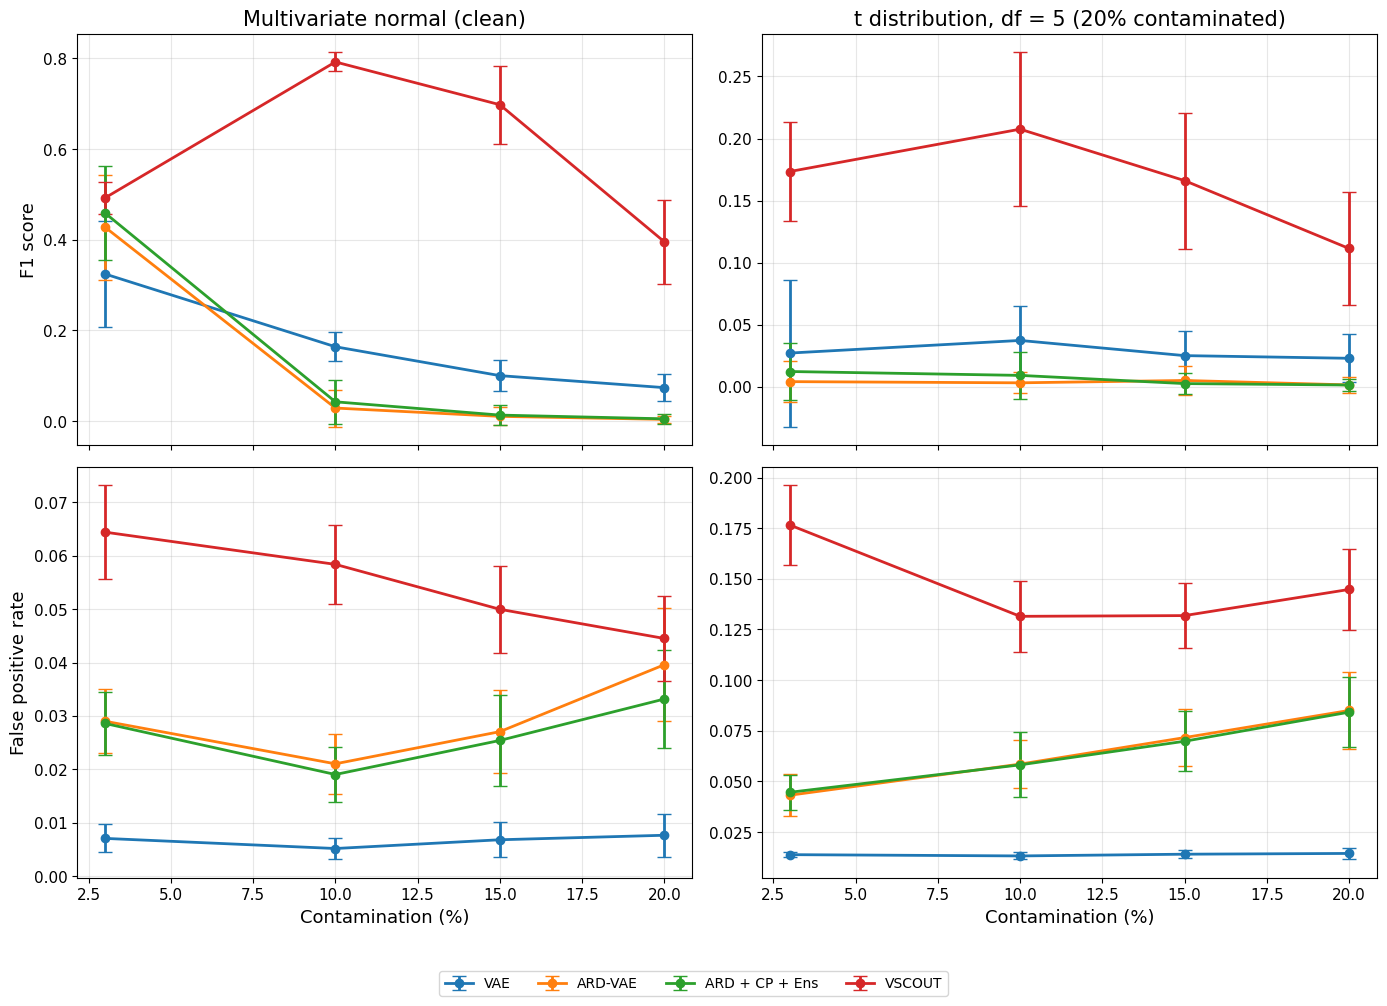

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("contamination_sensitivity_results.csv")

keep_variants = [
    "VAE_AllLatents",
    "ARDVAE_Mahalanobis",
    "ARDVAE_CP_Ensemble_NoRefine",
    "Full_VSCOUT"
]
df = df[df["Variant"].isin(keep_variants)].copy()

variant_map = {
    "VAE_AllLatents": "VAE",
    "ARDVAE_Mahalanobis": "ARD-VAE",
    "ARDVAE_CP_Ensemble_NoRefine": "ARD + CP + Ens",
    "Full_VSCOUT": "VSCOUT",
}
df["Variant"] = df["Variant"].map(variant_map)

scenario_map = {
    "DGP1_MVN": "Multivariate normal",
    "DGP4_MixedNormalT": "t distribution, df = 5",
}
df["ScenarioLabel"] = df["Scenario"].map(scenario_map)

metrics = ["F1", "FPR"]

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "legend.fontsize": 10,
})

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

for row, metric in enumerate(metrics):

    agg = (
        df.groupby(["ScenarioLabel", "Variant", "Contamination"], as_index=False)[metric]
        .agg(["mean", "std"])
        .reset_index()
    )

    if "mean" not in agg.columns:
        agg.columns = ["ScenarioLabel", "Variant", "Contamination", "mean", "std"]

    for col, scenario in enumerate(["Multivariate normal", "t distribution, df = 5"]):

        ax = axes[row, col]
        sub = agg[agg["ScenarioLabel"] == scenario]

        for variant in ["VAE", "ARD-VAE", "ARD + CP + Ens", "VSCOUT"]:
            tmp = sub[sub["Variant"] == variant].sort_values("Contamination")
            if tmp.empty:
                continue

            ax.errorbar(
                tmp["Contamination"] * 100,
                tmp["mean"],
                yerr=tmp["std"].fillna(0),
                marker="o",
                linestyle="-",
                linewidth=2,
                markersize=6,
                capsize=5,
                label=variant
            )

        # Titles
        if row == 0:
            ax.set_title(f"{scenario} (clean)" if col == 0 else f"{scenario} (20% contaminated)")

        ax.grid(True, alpha=0.3)

        if col == 0:
            ax.set_ylabel("F1 score" if metric == "F1" else "False positive rate")

        if row == 1:
            ax.set_xlabel("Contamination (%)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=True, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("contamination_sensitivity_final.png", dpi=300, bbox_inches="tight")
plt.show()

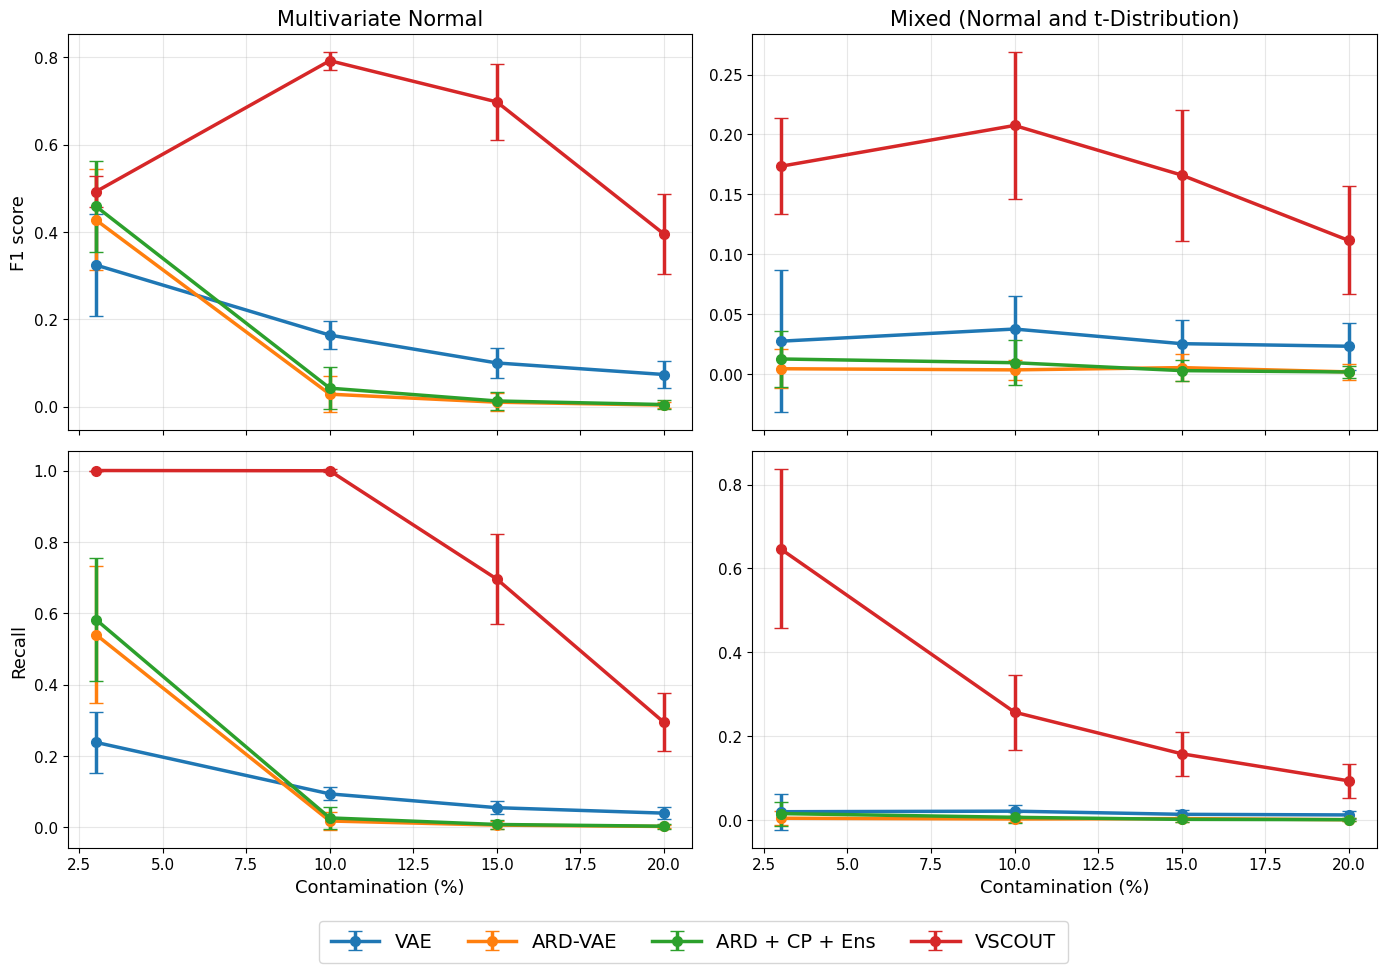

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# Load results
# --------------------------------------------------
df = pd.read_csv("contamination_sensitivity_results.csv")

keep_variants = [
    "VAE_AllLatents",
    "ARDVAE_Mahalanobis",
    "ARDVAE_CP_Ensemble_NoRefine",
    "Full_VSCOUT"
]
df = df[df["Variant"].isin(keep_variants)].copy()

# Paper-style labels
variant_map = {
    "VAE_AllLatents": "VAE",
    "ARDVAE_Mahalanobis": "ARD-VAE",
    "ARDVAE_CP_Ensemble_NoRefine": "ARD + CP + Ens",
    "Full_VSCOUT": "VSCOUT",
}
df["Variant"] = df["Variant"].map(variant_map)

scenario_map = {
    "DGP1_MVN": "Multivariate Normal",
    "DGP4_MixedNormalT": "Mixed (Normal and t-Distribution)",
}
df["ScenarioLabel"] = df["Scenario"].map(scenario_map)

metrics = ["F1", "Recall"]

# --------------------------------------------------
# Styling (match your paper figures)
# --------------------------------------------------
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
})

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

for row, metric in enumerate(metrics):

    agg = (
        df.groupby(["ScenarioLabel", "Variant", "Contamination"], as_index=False)[metric]
        .agg(["mean", "std"])
        .reset_index()
    )

    if "mean" not in agg.columns:
        agg.columns = ["ScenarioLabel", "Variant", "Contamination", "mean", "std"]

    for col, scenario in enumerate(["Multivariate Normal", "Mixed (Normal and t-Distribution)"]):

        ax = axes[row, col]
        sub = agg[agg["ScenarioLabel"] == scenario]

        for variant in ["VAE", "ARD-VAE", "ARD + CP + Ens", "VSCOUT"]:
            tmp = sub[sub["Variant"] == variant].sort_values("Contamination")
            if tmp.empty:
                continue

            ax.errorbar(
                tmp["Contamination"] * 100,
                tmp["mean"],
                yerr=tmp["std"].fillna(0),
                marker="o",
                linestyle="-",
                linewidth=2.5,   # thicker lines
                markersize=7,    # bigger markers
                capsize=5,
                label=variant
            )

        # Titles (paper style)
        if row == 0:
            ax.set_title(scenario)

        ax.grid(True, alpha=0.3)

        # Y-axis labels
        if col == 0:
            ax.set_ylabel("F1 score" if metric == "F1" else "Recall")

        # X-axis labels only bottom row
        if row == 1:
            ax.set_xlabel("Contamination (%)")

# --------------------------------------------------
# Shared legend (FIXED VERSION)
# --------------------------------------------------
handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    frameon=True,
    fontsize=14,          # BIG FIX (larger text)
    handlelength=2.5,     # longer line segments
    handletextpad=0.8,
    columnspacing=1.8,
    borderpad=0.6,
    bbox_to_anchor=(0.5, 0.02)   # moved upward slightly
)

plt.tight_layout(rect=[0, 0.08, 1, 1])  # more room for legend
plt.savefig("contamination_sensitivity_F1_Recall_2x2.png", dpi=300, bbox_inches="tight")
plt.show()